Here we have our WGAN-GP.

In [1]:
# Imports
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import math
import matplotlib.pyplot as plt
from PIL import Image
import random
from torchvision import transforms
import torchvision.transforms.functional as TF

In [2]:
torch.manual_seed(111)

device = ""
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [ ]:
# Download and unzip dataset
!kaggle datasets download -d jahysama/animal-crossing-new-horizons-all-villagers -p data
!unzip -o data/*.zip -d data

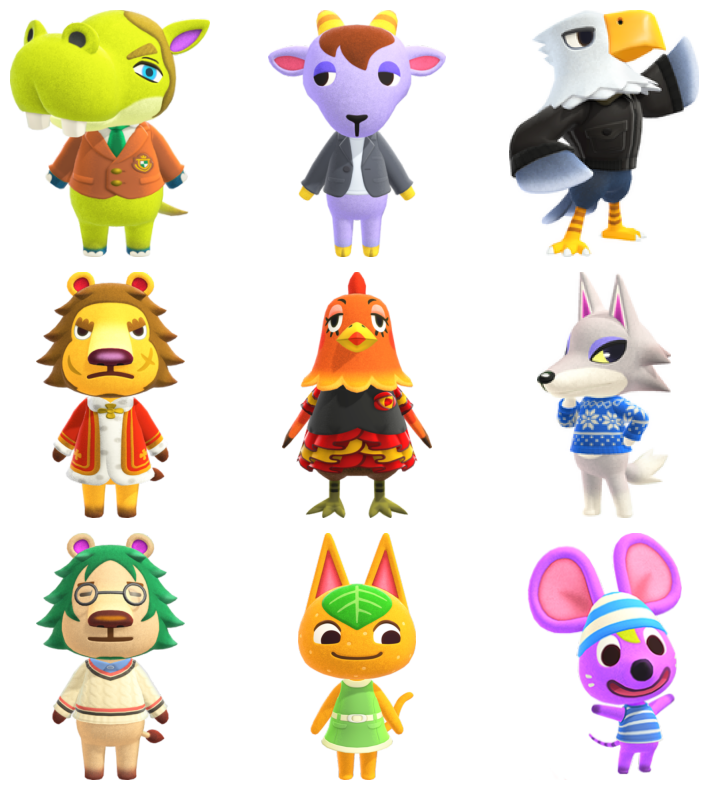

In [3]:
# Inspect the dataset
import os

base_path = "data" 
os.listdir(base_path)

image_paths = []

for root, _, files in os.walk(base_path):
    for f in files:
        if f.lower().endswith(".png"):
            image_paths.append(os.path.join(root, f))

sample_paths = random.sample(image_paths, 9)

plt.figure(figsize=(8, 8))

for i, path in enumerate(sample_paths):
    img = Image.open(path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [4]:
sizes = []

for path in image_paths:
    img = Image.open(path)
    sizes.append(img.size)

widths, heights = zip(*sizes)

print("Avg width:", sum(widths)/len(widths))
print("Avg height:", sum(heights)/len(heights))

Avg width: 216.67091836734693
Avg height: 348.82142857142856


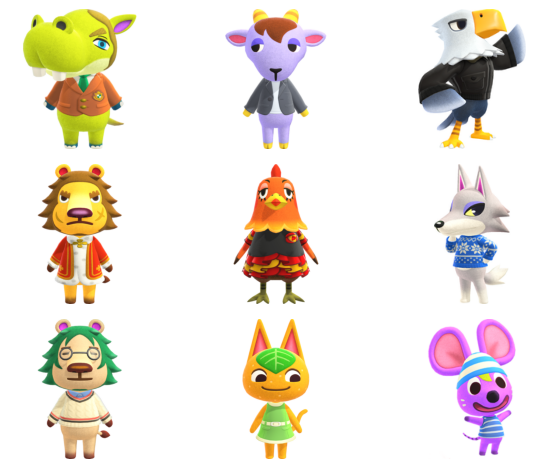

In [5]:
# Helper functions for preprocessing data

# Add white pixels to the image to make it square.
def add_padding(img):
  w, h = img.size
  largest_side = max(w, h)

  pad_left = (largest_side - w) // 2
  pad_top = (largest_side - h) // 2

  pad_right = largest_side - w - pad_left
  pad_bottom = largest_side - h - pad_top

  padding = (pad_left, pad_top, pad_right, pad_bottom)
  return TF.pad(img, padding, fill=255)
  
# Preprocesses image and returns a tensor
def preprocess_image(img):
    img = Image.open(img)
    # Handle transparent background
    if img.mode == "RGBA":
        bg = Image.new("RGB", img.size, (255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        img = bg
    else:
        img = img.convert("RGB")

    # Add padding to make image square
    square_img = add_padding(img)

    # Resize and transform image to tensor
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    return transform(img)


# Visualise the padded samples.
for i, path in enumerate(sample_paths):
    img = Image.open(path)
    if img.mode == "RGBA":
        bg = Image.new("RGB", img.size, (255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        img = bg
    else:
        img = img.convert("RGB")

    plt.subplot(3, 3, i + 1)
    plt.imshow(add_padding(img))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Data preparation
training_data = torch.stack([
    preprocess_image(p) for p in image_paths
])

print(training_data.shape)

batch_size = 62
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)


torch.Size([392, 3, 64, 64])


In [7]:
# Discriminator (or critic)

# Image -> Scalar
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0),
        )
    def forward(self, x):
        output = self.model(x).view(-1)
        return output    
        

In [8]:
# Generator

# Noise -> Image
class Generator(nn.Module):
    def __init__(self,latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 512 * 4 * 4),
            nn.ReLU(True),

            nn.Unflatten(1, (512, 4, 4)),
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1,bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1,bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(32, 3, 3, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        output = self.model(x)
        return output    

In [9]:
# Hyperparameters and optimizers
latent_dim = 100
lr = 0.0002

fixed_noise = torch.randn(16, latent_dim).to(device)

discriminator = Discriminator().to(device)
generator = Generator(latent_dim=latent_dim).to(device)

optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.0, 0.9)) # cuz ADAM is bae <3
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.0, 0.9))

Epoch [1/10]  D_loss: -119.7231  G_loss: -72.2749
Epoch [2/10]  D_loss: -117.3614  G_loss: -72.0036
Epoch [3/10]  D_loss: -86.6053  G_loss: -54.8363
Epoch [4/10]  D_loss: -71.2806  G_loss: -52.2092
Epoch [5/10]  D_loss: -74.4380  G_loss: -32.6545
Epoch [6/10]  D_loss: -44.4556  G_loss: -55.1316
Epoch [7/10]  D_loss: -47.4435  G_loss: -56.5971
Epoch [8/10]  D_loss: -48.6934  G_loss: -47.6427
Epoch [9/10]  D_loss: -44.0951  G_loss: -42.8913
Epoch [10/10]  D_loss: -42.7500  G_loss: -46.2557


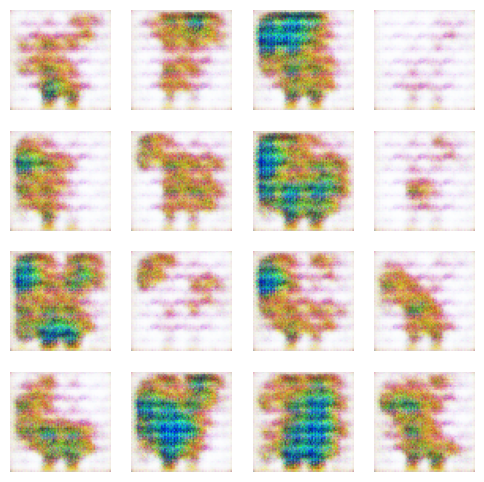

In [10]:
# Training loop
g_losses = []
d_losses = []
visualization_interval = 10
n_discriminator = 5
lambda_gp = 10 # gradient penalty
num_epochs = 10

# The gradient penalty is based on the compute_gradient_penalty function found here:
#https://aneelabashir425.medium.com/medium-article-tackling-mode-collapse-in-gans-from-dcgan-to-wgan-gp-0b31c7ac3692

def gradient_penalty(discriminator, real, fake, device=device):
    batch_size = real.size(0)

    epsilon = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolated = epsilon * real + (1 - epsilon) * fake
    interpolated.requires_grad_(True)

    mixed_scores = discriminator(interpolated)

    gradients = torch.autograd.grad(
        inputs=interpolated,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,
    )[0]

    gradients_norm = gradients.view(batch_size, -1).norm(2, dim=1)

    gradient_penalty = torch.mean((gradients_norm - 1) ** 2)
    return gradient_penalty

for epoch in range(num_epochs):
    for real_images in train_dataloader:
        batch_size = real_images.size(0)
        real_images = real_images.to(device)
        
        # Train the discriminator/critic
        for _ in range(n_discriminator):
            noise = torch.randn(batch_size, latent_dim).to(device)
            gen_images = generator(noise)

            d_real = discriminator(real_images)
            d_gen = discriminator(gen_images.detach())

            gp = gradient_penalty(discriminator,real_images, gen_images.detach())

            d_loss = -(torch.mean(d_real) - torch.mean(d_gen)) + lambda_gp * gp

            optimizer_discriminator.zero_grad()
            d_loss.backward()
            optimizer_discriminator.step()

        # Train the generator
        noise = torch.randn(batch_size, latent_dim).to(device)
        gen_images = generator(noise)

        g_loss = -torch.mean(discriminator(gen_images))

        optimizer_generator.zero_grad()
        g_loss.backward()
        optimizer_generator.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}]  D_loss: {d_loss.item():.4f}  G_loss: {g_loss.item():.4f}")
    
    # Visualization
    if (epoch + 1) % visualization_interval == 0:
        with torch.no_grad():
            synthetic_images = generator(fixed_noise).detach().cpu()

        grid = synthetic_images[:16]
        grid = (grid + 1) / 2  # [-1,1] → [0,1]

        fig, axes = plt.subplots(4, 4, figsize=(6, 6))
        for i, ax in enumerate(axes.flatten()):
            img = grid[i].permute(1, 2, 0)
            ax.imshow(img)
            ax.axis("off")
        plt.show()

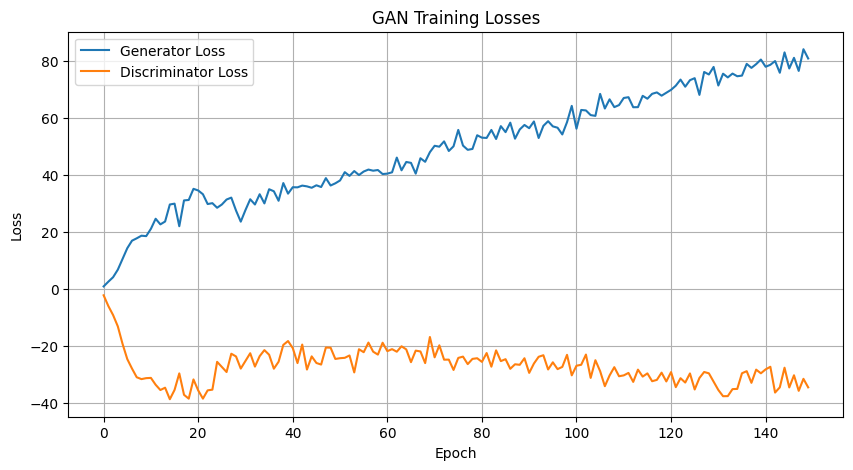

In [34]:
# Plot losses after training
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.grid(True)

plt.show()

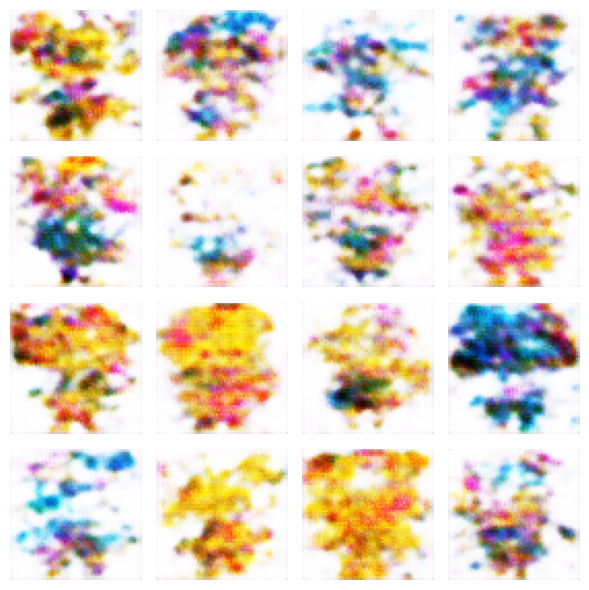

In [ ]:
# Visualizes 16 random images
def show_generated_images(generator, latent_dim, num_images=16, device="cpu"):
    generator.eval()  # set to eval mode

    with torch.no_grad():
        noise = torch.randn(num_images, latent_dim).to(device)
        fake_images = generator(noise).cpu()

    # Rescale from [-1, 1] → [0, 1]
    fake_images = (fake_images + 1) / 2

    # Plot
    grid_size = int(num_images ** 0.5)
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))

    for i, ax in enumerate(axes.flatten()):
        img = fake_images[i].permute(1, 2, 0)  # CHW → HWC
        ax.imshow(img)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_generated_images(generator,latent_dim)